In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [9]:
(df == " ").sum()  #using this method to find blank spaces

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

#Replacing Blanks with 0 as tenure is also 0 and No totalcharges are recorded.

In [10]:
df['totalcharges'] = df['totalcharges'].replace(" ",'0')
df['totalcharges'] = df['totalcharges'].astype(float)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [12]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['customerid'].duplicated().sum()

np.int64(0)

#Converted value 0 or 1 of seniorcitizen column to Yes or No.

In [15]:
def func(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
df['seniorcitizen'] = df['seniorcitizen'].apply(func)

In [ ]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df['churn'].value_counts(normalize=True)*100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [29]:
df_clean = df.copy()
df_clean.to_csv("Cleaned_telco_customer_churn.csv", index=False)

C:\Users\Anshika verma\AppData\Local\Temp\ipykernel_7584\2171333299.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(data=df ,x ='churn', color='red', edgecolor='Black', palette='Set1')


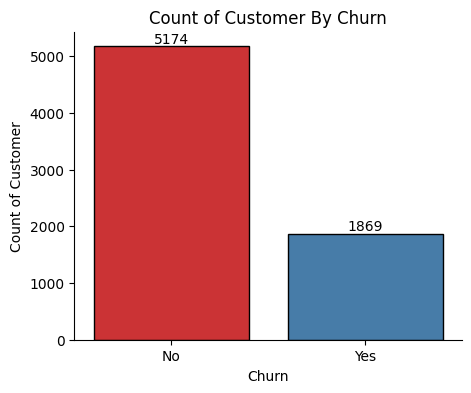

In [17]:
plt.figure(figsize=(5,4))
a = sns.countplot(data=df ,x ='churn', color='red', edgecolor='Black', palette='Set1')
a.bar_label(a.containers[0])     #using bar_label() to show count on the Bar
a.bar_label(a.containers[1])    
plt.title("Count of Customer By Churn")
plt.xlabel('Churn')
plt.ylabel('Count of Customer')
sns.despine()
plt.show()

C:\Users\Anshika verma\AppData\Local\Temp\ipykernel_7584\1060196108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(data=df, x='churn', color='red', edgecolor='Black', palette='Set1', legend=False)


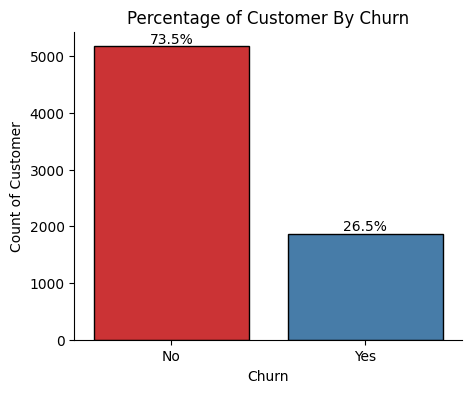

In [18]:
plt.figure(figsize=(5,4))

a = sns.countplot(data=df, x='churn', color='red', edgecolor='Black', palette='Set1', legend=False)
total = len(df)

# show percentage on bars
for container in a.containers:
    a.bar_label(container, labels=[f'{v.get_height()/total:.1%}' for v in container])

plt.title("Percentage of Customer By Churn")
plt.xlabel('Churn')
plt.ylabel('Count of Customer')
sns.despine()
plt.show()

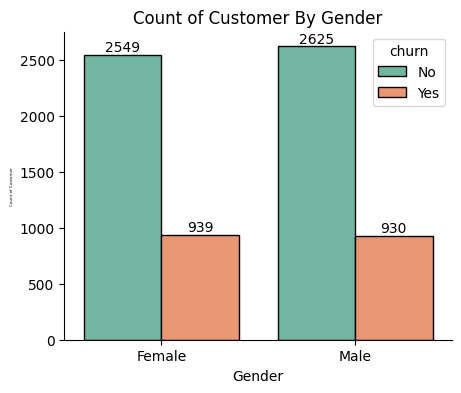

In [19]:
plt.figure(figsize=(5,4))
a = sns.countplot( data=df ,x = 'gender', color='purple', edgecolor='Black', hue= 'churn', palette='Set2')
a.bar_label(a.containers[0])     #using bar_label() to show count on the Bar
a.bar_label(a.containers[1])
plt.title("Count of Customer By Gender")
plt.xlabel('Gender')
plt.ylabel('Count of Customer',fontsize=3)
sns.despine()
plt.show()

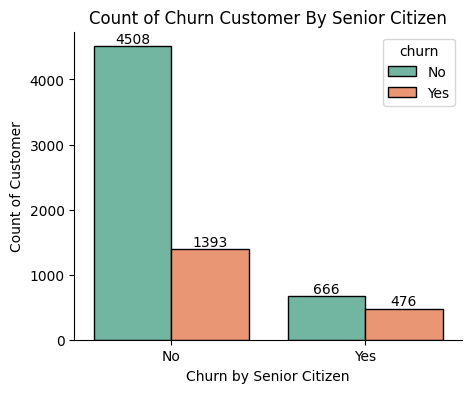

In [20]:
plt.figure(figsize=(5,4))
a = sns.countplot(data=df ,x ='seniorcitizen', hue='churn', color='Blue', edgecolor='Black', palette='Set2')
a.bar_label(a.containers[0])     #using bar_label() to show count on the Bar
a.bar_label(a.containers[1])
plt.title("Count of Churn Customer By Senior Citizen")
plt.xlabel('Churn by Senior Citizen')
plt.ylabel('Count of Customer')
sns.despine()
plt.show()

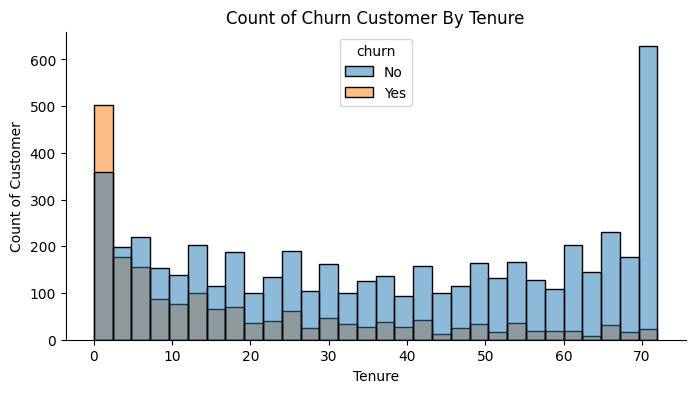

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(data=df ,x ='tenure', bins=30, hue="churn" , color='Blue', edgecolor='Black')
plt.title("Count of Churn Customer By Tenure")
plt.xlabel('Tenure')
plt.ylabel('Count of Customer')
sns.despine()
plt.show()

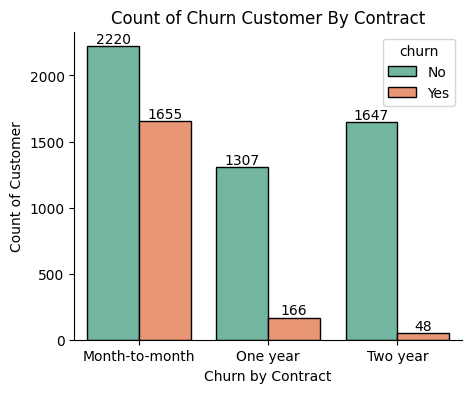

In [22]:
plt.figure(figsize=(5,4))
a = sns.countplot(data=df ,x ='contract', hue='churn', color='red', edgecolor='Black', palette='Set2')
a.bar_label(a.containers[0])     #using bar_label() to show count on the Bar
a.bar_label(a.containers[1])    
plt.title("Count of Churn Customer By Contract")
plt.xlabel('Churn by Contract')
plt.ylabel('Count of Customer')
sns.despine()
plt.show()

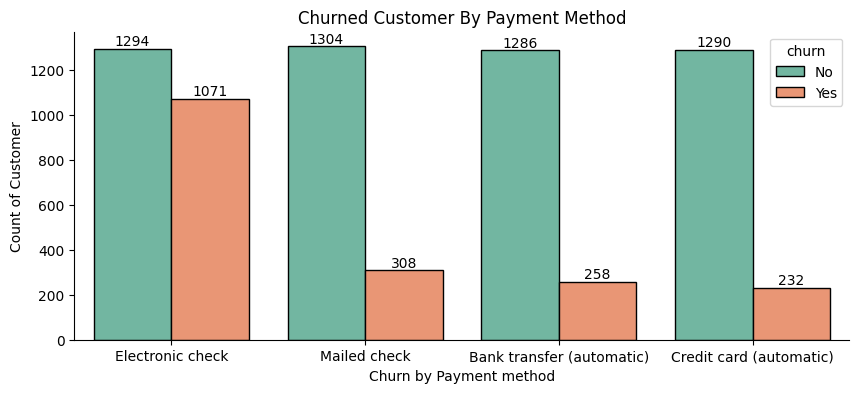

In [23]:
plt.figure(figsize=(10,4))
a = sns.countplot(data=df ,x ='paymentmethod', hue='churn', color='red', edgecolor='Black', palette='Set2')
a.bar_label(a.containers[0])     #using bar_label() to show count on the Bar
a.bar_label(a.containers[1])
plt.title("Churned Customer By Payment Method")
plt.xlabel('Churn by Payment method')
plt.ylabel('Count of Customer')
sns.despine()
plt.show()

In [30]:
from sqlalchemy import create_engine

# Mysql connection
username = "root"
password = "Mysql%40123"
host = "127.0.0.1"
port = "3306"
database = "mydatabase"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# write dataframe to mysql
table_name = "Telco_Customer_Churn_table"
df.to_sql(table_name, engine, if_exists="replace", index=False)

C:\Users\Anshika verma\AppData\Local\Temp\ipykernel_7584\1897159096.py:14: UserWarning: The provided table name 'Telco_Customer_Churn_table' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(table_name, engine, if_exists="replace", index=False)


7043

In [25]:
# read back sample
pd.read_sql(" SELECT * From telco_customer_churn_table LIMIT 5;", engine)

NameError: name 'engine' is not defined